# Phase 7: Trust Score Regression Models

Train ML models with train/validation/test split to detect overfitting and data leakage.

**Models:** Linear Regression, Random Forest, Gradient Boosting, XGBoost

**Metrics:** RMSE, MAE, R², Spearman Correlation

**Overfitting Detection:** Compare performance across all three datasets

In [1]:
!pip install statsmodels


In [2]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

## 1. Load & Prepare Data

In [3]:
# ── Load the fully engineered feature set (notebook 06 output) ───────────────
# featured_dataset.csv has 17 engineered features but no trust_score target.
# trust_scored_dataset.csv has the trust_score but fewer raw features.
# We join them on the 4-column natural key that both share.

import pandas as pd
import numpy as np

JOIN_KEYS = ['user_id', 'product_id', 'rating', 'reviewTime']

print("Loading datasets …")
df_feat  = pd.read_csv("../data/processed/featured_dataset.csv")
df_trust = pd.read_csv("../data/processed/trust_scored_dataset.csv",
                        usecols=JOIN_KEYS + ['trust_score'])

print(f"  featured_dataset   : {df_feat.shape}")
print(f"  trust_scored (keys): {df_trust.shape}")

# Merge — inner join keeps only rows present in both (should be 719 967)
df = df_feat.merge(df_trust, on=JOIN_KEYS, how='inner')
print(f"  merged             : {df.shape}")

# ── Define the 17 engineered features available after the merge ───────────────
# Organised into meaningful groups for ablation.
TEXT_FEATURES = [
    'review_length',      # raw text length
    'sentiment_score',    # polarity score
    'sentiment_extreme',  # binary: very positive / very negative
    'repetition_ratio',   # fraction of repeated words
    'exclamation_count',  # ! count
]

USER_BEHAVIORAL_FEATURES = [
    'user_review_count',      # total reviews by this user
    'user_review_frequency',  # avg days between reviews
]

PRODUCT_CONTEXT_FEATURES = [
    'product_review_count',   # how many reviews the product has
    'product_rating_variance',# spread of ratings for the product
    'product_popularity_log', # log-transformed review count
]

TEMPORAL_FEATURES = [
    'days_since_first_review', # review age
    'review_density',           # reviews per day window
    'review_time_gap',          # days since previous review by same user
]

RATING_FEATURES = [
    'rating',             # raw star rating
    'rating_deviation',   # deviation from product mean
    'verified',           # verified purchase flag
    'helpful_ratio',      # helpful / total votes
]

feature_cols = (TEXT_FEATURES + USER_BEHAVIORAL_FEATURES +
                PRODUCT_CONTEXT_FEATURES + TEMPORAL_FEATURES + RATING_FEATURES)

available_features = [c for c in feature_cols if c in df.columns]
missing_features   = [c for c in feature_cols if c not in df.columns]

X = df[available_features].fillna(0)
y = df['trust_score']

print(f"\nFeature groups loaded:")
print(f"  Text             : {len([f for f in TEXT_FEATURES if f in available_features])}/{len(TEXT_FEATURES)} features")
print(f"  User Behavioral  : {len([f for f in USER_BEHAVIORAL_FEATURES if f in available_features])}/{len(USER_BEHAVIORAL_FEATURES)} features")
print(f"  Product Context  : {len([f for f in PRODUCT_CONTEXT_FEATURES if f in available_features])}/{len(PRODUCT_CONTEXT_FEATURES)} features")
print(f"  Temporal         : {len([f for f in TEMPORAL_FEATURES if f in available_features])}/{len(TEMPORAL_FEATURES)} features")
print(f"  Rating           : {len([f for f in RATING_FEATURES if f in available_features])}/{len(RATING_FEATURES)} features")
print(f"  TOTAL available  : {len(available_features)}")
if missing_features:
    print(f"  Missing (skipped): {missing_features}")
print(f"\nTarget shape: {y.shape}")

Loading datasets …
  featured_dataset   : (719967, 46)
  trust_scored (keys): (719967, 5)
  merged             : (720547, 47)

Feature groups loaded:
  Text             : 5/5 features
  User Behavioral  : 2/2 features
  Product Context  : 3/3 features
  Temporal         : 3/3 features
  Rating           : 4/4 features
  TOTAL available  : 17

Target shape: (720547,)


## 2. Train/Validation/Test Split (60/20/20)

In [4]:
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print(f"Train: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Val:   {X_val.shape[0]} ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test:  {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")

Train: 432327 (60.0%)
Val:   144110 (20.0%)
Test:  144110 (20.0%)


## 3. Feature Scaling

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
print("Features scaled")

Features scaled


## 3.5 Feature Correlation Analysis

Analyze feature relationships to detect multicollinearity and understand feature importance.

In [6]:
# 3.5.1 Correlation with Target Variable
target_corr = X_train.corrwith(y_train).abs().sort_values(ascending=False)
target_corr_df = pd.DataFrame({
    'Feature': target_corr.index,
    'Correlation': target_corr.values
})

print("\n" + "="*80)
print("FEATURE CORRELATION WITH TARGET (trust_score)")
print("="*80)
print(target_corr_df.to_string(index=False))
print("="*80)

target_corr_df.to_csv('../results/reports/target_correlation.csv', index=False)
print("\nSaved: results/reports/target_correlation.csv")


FEATURE CORRELATION WITH TARGET (trust_score)
                Feature  Correlation
       rating_deviation     0.630997
               verified     0.449961
product_rating_variance     0.365982
      user_review_count     0.285263
                 rating     0.234766
        sentiment_score     0.150845
 product_popularity_log     0.105860
      sentiment_extreme     0.098744
          helpful_ratio     0.087050
  user_review_frequency     0.083354
   product_review_count     0.026405
         review_density     0.011778
days_since_first_review     0.011306
          review_length     0.007732
        review_time_gap     0.002145
       repetition_ratio     0.000710
      exclamation_count          NaN

Saved: results/reports/target_correlation.csv


In [7]:
# 3.5.2 Feature-to-Feature Correlation Matrix
import seaborn as sns

corr_matrix = X_train.corr()

# Find highly correlated pairs (> 0.8)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ))

if high_corr_pairs:
    print("\n" + "="*80)
    print("HIGH CORRELATION PAIRS (|r| > 0.8) - Potential Multicollinearity")
    print("="*80)
    for feat1, feat2, corr in high_corr_pairs:
        print(f"{feat1:30} <-> {feat2:30} : {corr:6.3f}")
    print("="*80)
else:
    print("\n✅ No high correlation pairs found (|r| > 0.8)")

# Plot correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/feature_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.close()
print("\nSaved: results/figures/feature_correlation_matrix.png")




✅ No high correlation pairs found (|r| > 0.8)

Saved: results/figures/feature_correlation_matrix.png


In [8]:
# 3.5.3 Multicollinearity Detection using VIF (Variance Inflation Factor)
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate VIF for each feature
# statsmodels requires numeric, finite (float) inputs.
X_vif = X_train.copy()
X_vif = X_vif.apply(pd.to_numeric, errors='coerce')
X_vif = X_vif.replace([np.inf, -np.inf], np.nan)
# Impute remaining missing values with column medians (then 0 as fallback).
X_vif = X_vif.fillna(X_vif.median(numeric_only=True))
X_vif = X_vif.fillna(0)

vif_data = pd.DataFrame({'Feature': X_vif.columns})
vif_values = []
for i in range(X_vif.shape[1]):
    try:
        vif_values.append(variance_inflation_factor(X_vif.values, i))
    except Exception:
        # If a column is constant/singular, VIF can fail; mark as inf.
        vif_values.append(np.inf)
vif_data['VIF'] = vif_values
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*80)
print("VARIANCE INFLATION FACTOR (VIF) - Multicollinearity Detection")
print("="*80)
print("VIF Interpretation:")
print("  1-5:   Low multicollinearity (acceptable)")
print("  5-10:  Moderate multicollinearity (caution)")
print("  >10:   High multicollinearity (problematic)")
print("="*80)
print(vif_data.to_string(index=False))
print("="*80)

# Flag problematic features
high_vif = vif_data[vif_data['VIF'] > 10]
if len(high_vif) > 0:
    print("\n⚠️  WARNING: High VIF detected for:")
    for _, row in high_vif.iterrows():
        print(f"  - {row['Feature']:30} VIF = {row['VIF']:.2f}")
    print("\nConsider removing or combining these features.")
else:
    print("\n✅ All features have acceptable VIF values (<10)")

vif_data.to_csv('../results/reports/vif_analysis.csv', index=False)
print("\nSaved: results/reports/vif_analysis.csv")


VARIANCE INFLATION FACTOR (VIF) - Multicollinearity Detection
VIF Interpretation:
  1-5:   Low multicollinearity (acceptable)
  5-10:  Moderate multicollinearity (caution)
  >10:   High multicollinearity (problematic)
                Feature  VIF
          review_length  inf
        sentiment_score  inf
      sentiment_extreme  inf
       repetition_ratio  inf
      exclamation_count  inf
      user_review_count  inf
  user_review_frequency  inf
   product_review_count  inf
product_rating_variance  inf
 product_popularity_log  inf
days_since_first_review  inf
         review_density  inf
        review_time_gap  inf
                 rating  inf
       rating_deviation  inf
               verified  inf
          helpful_ratio  inf

⚠️  WARNING: High VIF detected for:
  - review_length                  VIF = inf
  - sentiment_score                VIF = inf
  - sentiment_extreme              VIF = inf
  - repetition_ratio               VIF = inf
  - exclamation_count              VIF = i

## 4. Evaluation Function

In [9]:
def evaluate_model(y_true, y_pred, model_name, dataset_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    spearman, _ = spearmanr(y_true, y_pred)
    return {'Model': model_name, 'Dataset': dataset_name, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'Spearman': spearman}

## 5. Train Models

In [10]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_results = [
    evaluate_model(y_train, lr.predict(X_train_scaled), 'Linear Regression', 'Train'),
    evaluate_model(y_val, lr.predict(X_val_scaled), 'Linear Regression', 'Validation'),
    evaluate_model(y_test, lr.predict(X_test_scaled), 'Linear Regression', 'Test')
]
print("Linear Regression trained")

Linear Regression trained


In [11]:
rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_results = [
    evaluate_model(y_train, rf.predict(X_train), 'Random Forest', 'Train'),
    evaluate_model(y_val, rf.predict(X_val), 'Random Forest', 'Validation'),
    evaluate_model(y_test, rf.predict(X_test), 'Random Forest', 'Test')
]
print("Random Forest trained")

Random Forest trained


In [12]:
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
gb.fit(X_train, y_train)
gb_results = [
    evaluate_model(y_train, gb.predict(X_train), 'Gradient Boosting', 'Train'),
    evaluate_model(y_val, gb.predict(X_val), 'Gradient Boosting', 'Validation'),
    evaluate_model(y_test, gb.predict(X_test), 'Gradient Boosting', 'Test')
]
print("Gradient Boosting trained")

Gradient Boosting trained


In [13]:
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train)
xgb_results = [
    evaluate_model(y_train, xgb.predict(X_train), 'XGBoost', 'Train'),
    evaluate_model(y_val, xgb.predict(X_val), 'XGBoost', 'Validation'),
    evaluate_model(y_test, xgb.predict(X_test), 'XGBoost', 'Test')
]
print("XGBoost trained")

XGBoost trained


## 5.5 K-Fold Cross-Validation

Perform 5-fold cross-validation to validate model stability and generalization.

In [14]:
from sklearn.model_selection import cross_val_score, KFold

# Setup 5-fold cross-validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Models to evaluate
cv_models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1)
}

print("\n" + "="*100)
print("K-FOLD CROSS-VALIDATION RESULTS (5 Folds)")
print("="*100)
print(f"{'Model':<25} {'Mean R²':>12} {'Std R²':>12} {'Min R²':>12} {'Max R²':>12}")
print("-" * 100)

cv_results = []

for name, model in cv_models.items():
    # Use scaled data for Linear Regression, raw data for tree-based models
    if name == 'Linear Regression':
        X_cv = X_train_scaled
    else:
        X_cv = X_train
    
    # Perform cross-validation
    scores = cross_val_score(model, X_cv, y_train, cv=kfold, 
                            scoring='r2', n_jobs=-1)
    
    cv_results.append({
        'Model': name,
        'Mean_R2': scores.mean(),
        'Std_R2': scores.std(),
        'Min_R2': scores.min(),
        'Max_R2': scores.max(),
        'Fold_Scores': scores
    })
    
    print(f"{name:<25} {scores.mean():>12.4f} {scores.std():>12.4f} "
          f"{scores.min():>12.4f} {scores.max():>12.4f}")

print("="*100)

# Save results
cv_df = pd.DataFrame([{
    'Model': r['Model'],
    'Mean_R2': r['Mean_R2'],
    'Std_R2': r['Std_R2'],
    'Min_R2': r['Min_R2'],
    'Max_R2': r['Max_R2']
} for r in cv_results])

cv_df.to_csv('../results/reports/cross_validation_results.csv', index=False)
print("\nSaved: results/reports/cross_validation_results.csv")


K-FOLD CROSS-VALIDATION RESULTS (5 Folds)
Model                          Mean R²       Std R²       Min R²       Max R²
----------------------------------------------------------------------------------------------------
Linear Regression               0.6900       0.0037       0.6836       0.6939
Random Forest                   0.8407       0.0010       0.8393       0.8418
Gradient Boosting               0.8439       0.0010       0.8427       0.8452
XGBoost                         0.8446       0.0011       0.8433       0.8459

Saved: results/reports/cross_validation_results.csv


In [15]:
# Visualize cross-validation results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Mean R² with error bars
models = [r['Model'] for r in cv_results]
means = [r['Mean_R2'] for r in cv_results]
stds = [r['Std_R2'] for r in cv_results]

ax1.barh(models, means, xerr=stds, capsize=5, color='steelblue', alpha=0.7)
ax1.set_xlabel('R² Score', fontweight='bold')
ax1.set_title('Cross-Validation Mean R² (±1 Std)', fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# Plot 2: Box plot of fold scores
fold_data = [r['Fold_Scores'] for r in cv_results]
bp = ax2.boxplot(fold_data, labels=models, vert=False, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightcoral')
    patch.set_alpha(0.7)
ax2.set_xlabel('R² Score', fontweight='bold')
ax2.set_title('Cross-Validation Score Distribution', fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/figures/cross_validation_analysis.png', dpi=300, bbox_inches='tight')
plt.close()
print("\nSaved: results/figures/cross_validation_analysis.png")


Saved: results/figures/cross_validation_analysis.png


## 6. Comprehensive Results

In [16]:
all_results = pd.DataFrame(lr_results + rf_results + gb_results + xgb_results)

print("\n" + "="*100)
print("ALL MODELS - TRAIN/VALIDATION/TEST PERFORMANCE")
print("="*100)
print(all_results.to_string(index=False))
print("="*100)

all_results.to_csv('../results/reports/model_performance_all_datasets.csv', index=False)


ALL MODELS - TRAIN/VALIDATION/TEST PERFORMANCE
            Model    Dataset     RMSE      MAE       R2  Spearman
Linear Regression      Train 0.070239 0.044826 0.690088  0.858251
Linear Regression Validation 0.070818 0.045120 0.686221  0.857958
Linear Regression       Test 0.070668 0.045184 0.685040  0.856964
    Random Forest      Train 0.042345 0.019282 0.887364  0.944430
    Random Forest Validation 0.050703 0.023305 0.839156  0.930567
    Random Forest       Test 0.050817 0.023398 0.837137  0.930370
Gradient Boosting      Train 0.049463 0.024679 0.846315  0.931534
Gradient Boosting Validation 0.050210 0.025005 0.842265  0.930759
Gradient Boosting       Test 0.050220 0.025076 0.840937  0.930615
          XGBoost      Train 0.049017 0.023875 0.849071  0.932662
          XGBoost Validation 0.050064 0.024347 0.843186  0.931356
          XGBoost       Test 0.050085 0.024418 0.841794  0.931243


## 7. Overfitting & Data Leakage Analysis

In [17]:
models = ['Linear Regression', 'Random Forest', 'Gradient Boosting', 'XGBoost']
analysis = []

for model in models:
    m_data = all_results[all_results['Model'] == model]
    train_r2 = m_data[m_data['Dataset'] == 'Train']['R2'].values[0]
    val_r2 = m_data[m_data['Dataset'] == 'Validation']['R2'].values[0]
    test_r2 = m_data[m_data['Dataset'] == 'Test']['R2'].values[0]
    
    train_rmse = m_data[m_data['Dataset'] == 'Train']['RMSE'].values[0]
    val_rmse = m_data[m_data['Dataset'] == 'Validation']['RMSE'].values[0]
    test_rmse = m_data[m_data['Dataset'] == 'Test']['RMSE'].values[0]
    
    train_spear = m_data[m_data['Dataset'] == 'Train']['Spearman'].values[0]
    val_spear = m_data[m_data['Dataset'] == 'Validation']['Spearman'].values[0]
    test_spear = m_data[m_data['Dataset'] == 'Test']['Spearman'].values[0]
    
    r2_gap = train_r2 - test_r2
    rmse_gap = test_rmse - train_rmse
    spear_gap = train_spear - test_spear
    
    analysis.append({
        'Model': model,
        'Train_R2': train_r2, 'Val_R2': val_r2, 'Test_R2': test_r2,
        'R2_Gap': r2_gap,
        'Train_RMSE': train_rmse, 'Val_RMSE': val_rmse, 'Test_RMSE': test_rmse,
        'RMSE_Gap': rmse_gap,
        'Train_Spear': train_spear, 'Val_Spear': val_spear, 'Test_Spear': test_spear,
        'Spear_Gap': spear_gap
    })

analysis_df = pd.DataFrame(analysis)

print("\n" + "="*120)
print("OVERFITTING ANALYSIS - R² METRICS")
print("="*120)
print(analysis_df[['Model', 'Train_R2', 'Val_R2', 'Test_R2', 'R2_Gap']].to_string(index=False))
print("="*120)

print("\n" + "="*120)
print("OVERFITTING ANALYSIS - RMSE METRICS")
print("="*120)
print(analysis_df[['Model', 'Train_RMSE', 'Val_RMSE', 'Test_RMSE', 'RMSE_Gap']].to_string(index=False))
print("="*120)

print("\n" + "="*120)
print("OVERFITTING ANALYSIS - SPEARMAN CORRELATION (Ranking Quality)")
print("="*120)
print(analysis_df[['Model', 'Train_Spear', 'Val_Spear', 'Test_Spear', 'Spear_Gap']].to_string(index=False))
print("="*120)

analysis_df.to_csv('../results/reports/overfitting_analysis.csv', index=False)


OVERFITTING ANALYSIS - R² METRICS
            Model  Train_R2   Val_R2  Test_R2   R2_Gap
Linear Regression  0.690088 0.686221 0.685040 0.005048
    Random Forest  0.887364 0.839156 0.837137 0.050227
Gradient Boosting  0.846315 0.842265 0.840937 0.005378
          XGBoost  0.849071 0.843186 0.841794 0.007277

OVERFITTING ANALYSIS - RMSE METRICS
            Model  Train_RMSE  Val_RMSE  Test_RMSE  RMSE_Gap
Linear Regression    0.070239  0.070818   0.070668  0.000429
    Random Forest    0.042345  0.050703   0.050817  0.008472
Gradient Boosting    0.049463  0.050210   0.050220  0.000758
          XGBoost    0.049017  0.050064   0.050085  0.001068

OVERFITTING ANALYSIS - SPEARMAN CORRELATION (Ranking Quality)
            Model  Train_Spear  Val_Spear  Test_Spear  Spear_Gap
Linear Regression     0.858251   0.857958    0.856964   0.001288
    Random Forest     0.944430   0.930567    0.930370   0.014060
Gradient Boosting     0.931534   0.930759    0.930615   0.000919
          XGBoost     0.9

## 8. Data Leakage & Overfitting Detection

In [18]:
print("\n" + "="*120)
print("DATA LEAKAGE & OVERFITTING DETECTION")
print("="*120)

for idx, row in analysis_df.iterrows():
    print(f"\n{row['Model']}:")
    print("-" * 100)
    
    # Check 1: Validation between train and test
    val_between = (row['Val_R2'] <= row['Train_R2']) and (row['Val_R2'] >= row['Test_R2'])
    print(f"  ✓ Val R² between Train and Test: {val_between}")
    print(f"    Train: {row['Train_R2']:.4f}, Val: {row['Val_R2']:.4f}, Test: {row['Test_R2']:.4f}")
    
    # Check 2: Overfitting (R² gap)
    overfitting = row['R2_Gap'] > 0.05
    print(f"  ✓ Overfitting detected (R² gap > 0.05): {overfitting}")
    print(f"    R² Gap (Train - Test): {row['R2_Gap']:.4f}")
    
    # Check 3: RMSE increases from train to test
    rmse_increase = row['Test_RMSE'] >= row['Train_RMSE']
    print(f"  ✓ RMSE increases Train→Test (expected): {rmse_increase}")
    print(f"    Train: {row['Train_RMSE']:.4f}, Test: {row['Test_RMSE']:.4f}")
    
    # Check 4: Spearman consistency
    spear_consistent = row['Spear_Gap'] < 0.05
    print(f"  ✓ Spearman consistent (gap < 0.05): {spear_consistent}")
    print(f"    Train: {row['Train_Spear']:.4f}, Test: {row['Test_Spear']:.4f}")
    
    # Check 5: Val-Test gap small
    val_test_gap = abs(row['Val_R2'] - row['Test_R2'])
    val_proxy = val_test_gap < 0.03
    print(f"  ✓ Val is good proxy for Test (gap < 0.03): {val_proxy}")
    print(f"    Val-Test R² gap: {val_test_gap:.4f}")
    
    # Overall health
    checks = [val_between, not overfitting, rmse_increase, spear_consistent, val_proxy]
    health = sum(checks) / len(checks) * 100
    print(f"\n  Model Health Score: {health:.0f}% ({sum(checks)}/5 checks passed)")
    
    if health >= 80:
        print(f"  Status: ✅ HEALTHY - No significant issues")
    elif health >= 60:
        print(f"  Status: ⚠️  WARNING - Minor issues detected")
    else:
        print(f"  Status: ❌ CRITICAL - Significant overfitting/leakage")

print("\n" + "="*120)


DATA LEAKAGE & OVERFITTING DETECTION

Linear Regression:
----------------------------------------------------------------------------------------------------
  ✓ Val R² between Train and Test: True
    Train: 0.6901, Val: 0.6862, Test: 0.6850
  ✓ Overfitting detected (R² gap > 0.05): False
    R² Gap (Train - Test): 0.0050
  ✓ RMSE increases Train→Test (expected): True
    Train: 0.0702, Test: 0.0707
  ✓ Spearman consistent (gap < 0.05): True
    Train: 0.8583, Test: 0.8570
  ✓ Val is good proxy for Test (gap < 0.03): True
    Val-Test R² gap: 0.0012

  Model Health Score: 100% (5/5 checks passed)
  Status: ✅ HEALTHY - No significant issues

Random Forest:
----------------------------------------------------------------------------------------------------
  ✓ Val R² between Train and Test: True
    Train: 0.8874, Val: 0.8392, Test: 0.8371
  ✓ Overfitting detected (R² gap > 0.05): True
    R² Gap (Train - Test): 0.0502
  ✓ RMSE increases Train→Test (expected): True
    Train: 0.0423, T

## 9. Visualizations

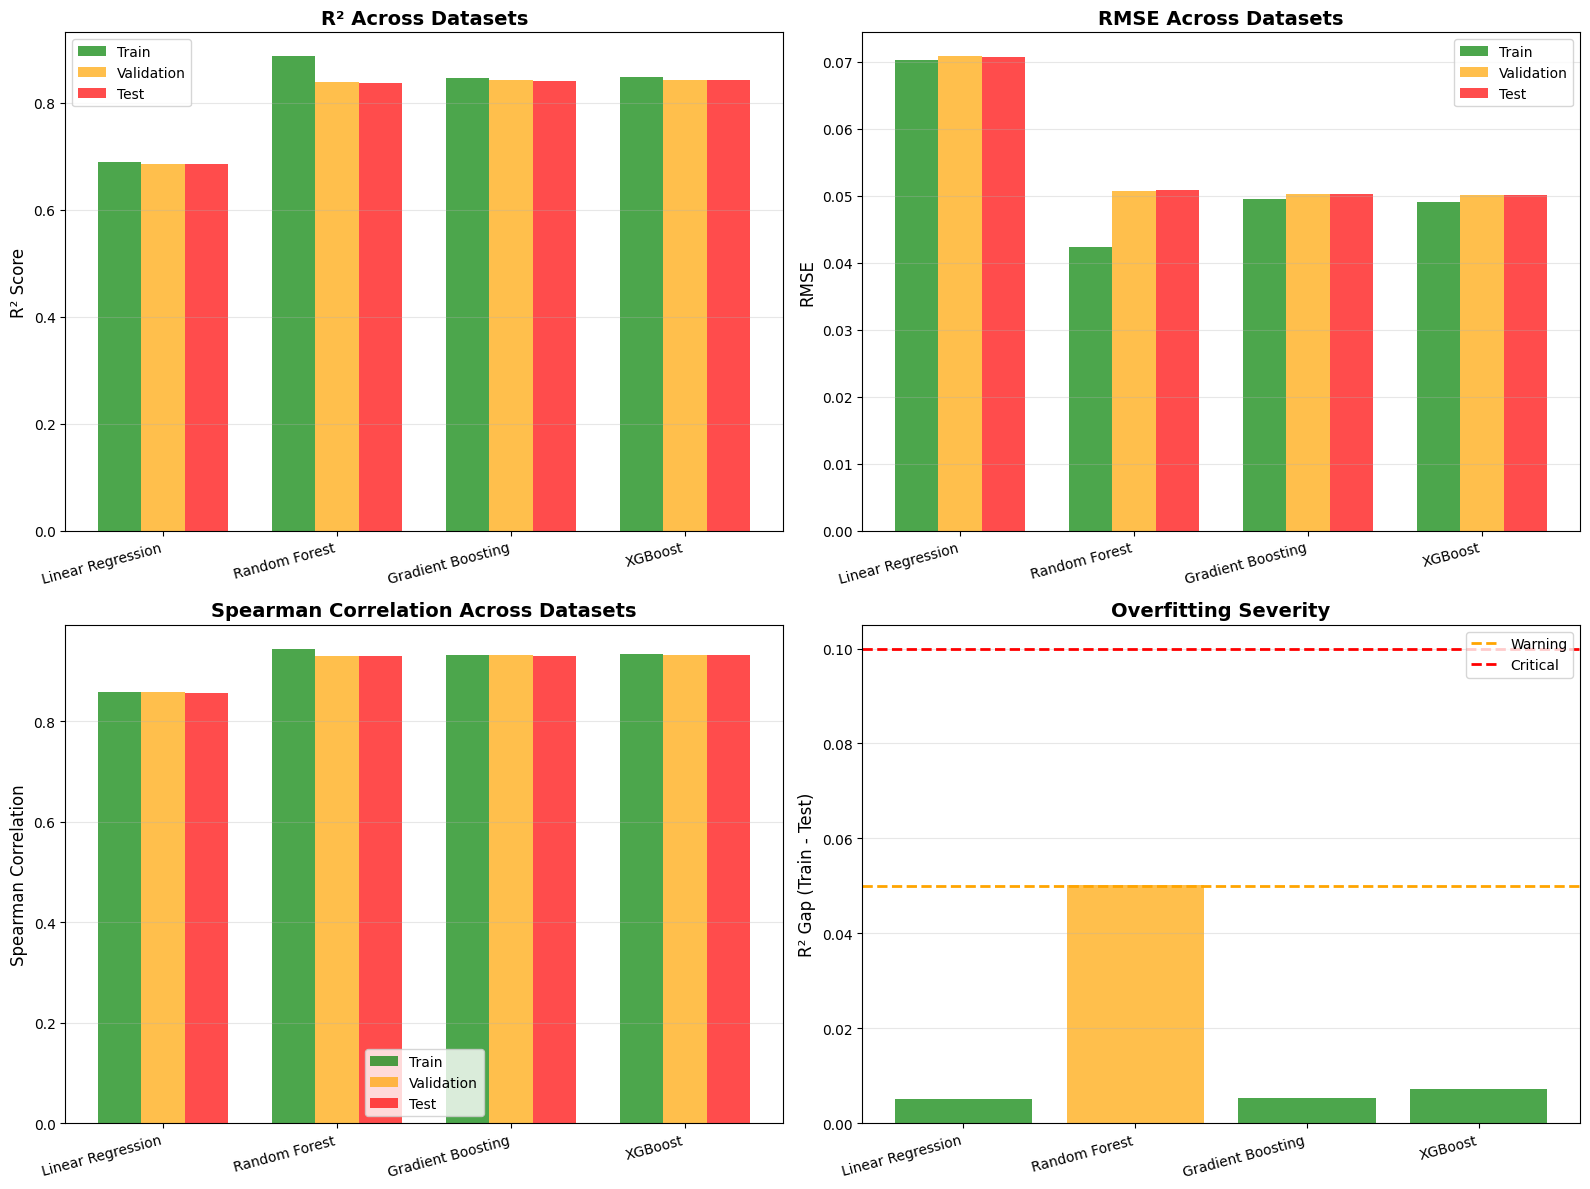

Visualization saved


In [19]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

models_list = analysis_df['Model'].tolist()
x = np.arange(len(models_list))
width = 0.25

# R² comparison
axes[0, 0].bar(x - width, analysis_df['Train_R2'], width, label='Train', color='green', alpha=0.7)
axes[0, 0].bar(x, analysis_df['Val_R2'], width, label='Validation', color='orange', alpha=0.7)
axes[0, 0].bar(x + width, analysis_df['Test_R2'], width, label='Test', color='red', alpha=0.7)
axes[0, 0].set_ylabel('R² Score', fontsize=12)
axes[0, 0].set_title('R² Across Datasets', fontsize=14, fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(models_list, rotation=15, ha='right')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# RMSE comparison
axes[0, 1].bar(x - width, analysis_df['Train_RMSE'], width, label='Train', color='green', alpha=0.7)
axes[0, 1].bar(x, analysis_df['Val_RMSE'], width, label='Validation', color='orange', alpha=0.7)
axes[0, 1].bar(x + width, analysis_df['Test_RMSE'], width, label='Test', color='red', alpha=0.7)
axes[0, 1].set_ylabel('RMSE', fontsize=12)
axes[0, 1].set_title('RMSE Across Datasets', fontsize=14, fontweight='bold')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(models_list, rotation=15, ha='right')
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# Spearman comparison
axes[1, 0].bar(x - width, analysis_df['Train_Spear'], width, label='Train', color='green', alpha=0.7)
axes[1, 0].bar(x, analysis_df['Val_Spear'], width, label='Validation', color='orange', alpha=0.7)
axes[1, 0].bar(x + width, analysis_df['Test_Spear'], width, label='Test', color='red', alpha=0.7)
axes[1, 0].set_ylabel('Spearman Correlation', fontsize=12)
axes[1, 0].set_title('Spearman Correlation Across Datasets', fontsize=14, fontweight='bold')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(models_list, rotation=15, ha='right')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# R² Gap (overfitting severity)
colors = ['green' if x < 0.05 else 'orange' if x < 0.1 else 'red' for x in analysis_df['R2_Gap']]
axes[1, 1].bar(models_list, analysis_df['R2_Gap'], color=colors, alpha=0.7)
axes[1, 1].set_ylabel('R² Gap (Train - Test)', fontsize=12)
axes[1, 1].set_title('Overfitting Severity', fontsize=14, fontweight='bold')
axes[1, 1].set_xticklabels(models_list, rotation=15, ha='right')
axes[1, 1].axhline(y=0.05, color='orange', linestyle='--', linewidth=2, label='Warning')
axes[1, 1].axhline(y=0.1, color='red', linestyle='--', linewidth=2, label='Critical')
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/figures/overfitting_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualization saved")

## 9.5 Ablation Study

Measure the impact of each feature by removing them one at a time.

In [20]:
# ── Feature groups for ablation study ────────────────────────────────────────
# Each group is ablated as a unit — we measure what happens to model performance
# when that entire semantic group is withheld from training.

feature_group_ablation = {}

# Only include a group if at least one of its features is available
for group_name, group_features in [
    ('Text',            TEXT_FEATURES),
    ('User-Behavioral', USER_BEHAVIORAL_FEATURES),
    ('Product-Context', PRODUCT_CONTEXT_FEATURES),
    ('Temporal',        TEMPORAL_FEATURES),
    ('Rating',          RATING_FEATURES),
]:
    present = [f for f in group_features if f in available_features]
    if present:
        feature_group_ablation[group_name] = present

print("Feature Groups for Ablation Study:")
for group, feats in feature_group_ablation.items():
    print(f"  {group:20s}: {feats}")

print(f"\nTotal features across all groups : {sum(len(v) for v in feature_group_ablation.values())}")

Feature Groups for Ablation Study:
  Text                : ['review_length', 'sentiment_score', 'sentiment_extreme', 'repetition_ratio', 'exclamation_count']
  User-Behavioral     : ['user_review_count', 'user_review_frequency']
  Product-Context     : ['product_review_count', 'product_rating_variance', 'product_popularity_log']
  Temporal            : ['days_since_first_review', 'review_density', 'review_time_gap']
  Rating              : ['rating', 'rating_deviation', 'verified', 'helpful_ratio']

Total features across all groups : 17


In [21]:
# ── Ablation study: remove each feature GROUP, measure performance drop ───────
print("\n" + "="*100)
print("ABLATION STUDY — Feature Group Impact Analysis")
print("="*100)
print("Each row shows performance when that entire feature GROUP is removed.\n")

ablation_results = []

# Baseline: XGBoost on ALL available features
baseline_r2       = xgb.score(X_test, y_test)
baseline_spearman, _ = spearmanr(y_test, xgb.predict(X_test))
print(f"Baseline (all {len(available_features)} features): "
      f"R² = {baseline_r2:.4f}, Spearman = {baseline_spearman:.4f}\n")

for group_name, features_to_remove in feature_group_ablation.items():
    remaining = [f for f in available_features if f not in features_to_remove]
    if len(remaining) == 0:
        continue

    X_train_ab = X_train[remaining]
    X_test_ab  = X_test[remaining]

    model_ab = XGBRegressor(n_estimators=100, learning_rate=0.1,
                             max_depth=6, random_state=42, n_jobs=-1)
    model_ab.fit(X_train_ab, y_train)

    r2_ab       = model_ab.score(X_test_ab, y_test)
    spearman_ab, _ = spearmanr(y_test, model_ab.predict(X_test_ab))

    r2_drop       = (baseline_r2       - r2_ab)       / max(abs(baseline_r2), 1e-9) * 100
    spearman_drop = (baseline_spearman - spearman_ab) / max(abs(baseline_spearman), 1e-9) * 100

    removed_str = ", ".join(features_to_remove)
    ablation_results.append({
        'Feature_Group':          group_name,
        'Features_Removed':       removed_str,
        'N_Removed':              len(features_to_remove),
        'R2_Without':             round(r2_ab, 6),
        'R2_Degradation_%':       round(r2_drop, 4),
        'Spearman_Without':       round(spearman_ab, 6),
        'Spearman_Degradation_%': round(spearman_drop, 4),
    })

    print(f"Without [{group_name:20s}] ({len(features_to_remove)} feats removed) → "
          f"R² = {r2_ab:.4f} ({r2_drop:+6.2f}%), "
          f"Spearman = {spearman_ab:.4f} ({spearman_drop:+6.2f}%)")

print("="*100)


ABLATION STUDY — Feature Group Impact Analysis
Each row shows performance when that entire feature GROUP is removed.

Baseline (all 17 features): R² = 0.8418, Spearman = 0.9312

Without [Text                ] (5 feats removed) → R² = 0.7955 ( +5.50%), Spearman = 0.8967 ( +3.70%)
Without [User-Behavioral     ] (2 feats removed) → R² = 0.6795 (+19.28%), Spearman = 0.8476 ( +8.98%)
Without [Product-Context     ] (3 feats removed) → R² = 0.8418 ( +0.01%), Spearman = 0.9312 ( -0.00%)
Without [Temporal            ] (3 feats removed) → R² = 0.8420 ( -0.03%), Spearman = 0.9314 ( -0.01%)
Without [Rating              ] (4 feats removed) → R² = 0.3641 (+56.75%), Spearman = 0.6169 (+33.75%)


In [22]:
# ── Ablation summary ─────────────────────────────────────────────────────────
ablation_df = pd.DataFrame(ablation_results).sort_values('R2_Degradation_%', ascending=False)

print("\n" + "="*100)
print("ABLATION STUDY SUMMARY — Feature Groups Ranked by Importance")
print("="*100)
print(ablation_df[['Feature_Group','N_Removed','R2_Without','R2_Degradation_%',
                   'Spearman_Without','Spearman_Degradation_%']].to_string(index=False))
print("="*100)

critical = ablation_df[ablation_df['R2_Degradation_%'] > 5]
if len(critical) > 0:
    print("\nCRITICAL GROUPS (>5% R² drop when removed):")
    for _, row in critical.iterrows():
        print(f"  {row['Feature_Group']:20s} → {row['R2_Degradation_%']:6.2f}% R² degradation  "
              f"({row['N_Removed']} features)")
else:
    print("\nNo single feature group causes >5% R² drop.")

ablation_df.to_csv('../results/reports/ablation_study.csv', index=False)
print("\nSaved: results/reports/ablation_study.csv")

# Also export per-feature importance from the BASELINE XGBoost model
feat_imp_df = pd.DataFrame({
    'Feature':    available_features,
    'Importance': xgb.feature_importances_,
}).sort_values('Importance', ascending=False)

feat_imp_df.to_csv('../results/reports/feature_importance.csv', index=False)
print("Saved: results/reports/feature_importance.csv")

print("\nTop feature importances (XGBoost):")
print(feat_imp_df.head(10).to_string(index=False))


ABLATION STUDY SUMMARY — Feature Groups Ranked by Importance
  Feature_Group  N_Removed  R2_Without  R2_Degradation_%  Spearman_Without  Spearman_Degradation_%
         Rating          4    0.364052           56.7529          0.616918                 33.7533
User-Behavioral          2    0.679531           19.2758          0.847615                  8.9803
           Text          5    0.795453            5.5050          0.896745                  3.7045
Product-Context          3    0.841750            0.0052          0.931245                 -0.0002
       Temporal          3    0.842009           -0.0255          0.931352                 -0.0117

CRITICAL GROUPS (>5% R² drop when removed):
  Rating               →  56.75% R² degradation  (4 features)
  User-Behavioral      →  19.28% R² degradation  (2 features)
  Text                 →   5.50% R² degradation  (5 features)

Saved: results/reports/ablation_study.csv
Saved: results/reports/feature_importance.csv

Top feature importances

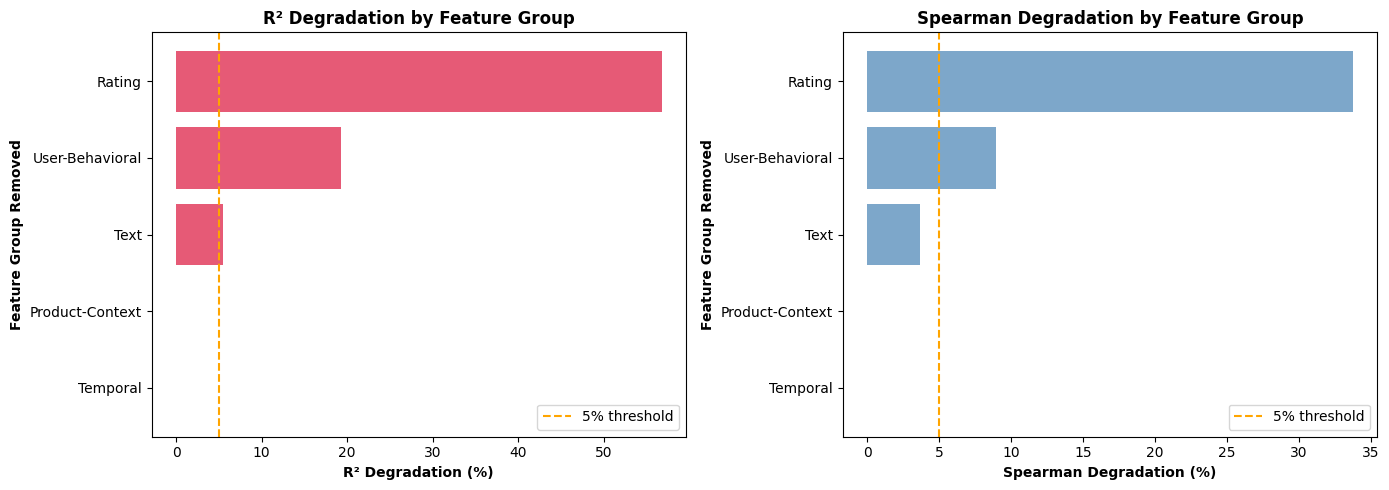

Saved: results/figures/ablation_study.png


In [23]:
# ── Ablation visualisation ────────────────────────────────────────────────────\n
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: R² Degradation per feature group\n
ax1.barh(ablation_df['Feature_Group'], ablation_df['R2_Degradation_%'],
         color='crimson', alpha=0.7)
ax1.set_xlabel('R² Degradation (%)', fontweight='bold')
ax1.set_ylabel('Feature Group Removed', fontweight='bold')
ax1.set_title('R² Degradation by Feature Group', fontweight='bold')
ax1.axvline(x=5, color='orange', linestyle='--', linewidth=1.5, label='5% threshold')
ax1.legend()
ax1.invert_yaxis()

# Plot 2: Spearman Degradation per feature group\n
ax2.barh(ablation_df['Feature_Group'], ablation_df['Spearman_Degradation_%'],
         color='steelblue', alpha=0.7)
ax2.set_xlabel('Spearman Degradation (%)', fontweight='bold')
ax2.set_ylabel('Feature Group Removed', fontweight='bold')
ax2.set_title('Spearman Degradation by Feature Group', fontweight='bold')
ax2.axvline(x=5, color='orange', linestyle='--', linewidth=1.5, label='5% threshold')
ax2.legend()
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig('../results/figures/ablation_study.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/figures/ablation_study.png")

## 10. Save Best Model

In [24]:
# Select best model based on test set Spearman
test_results = all_results[all_results['Dataset'] == 'Test'].sort_values('Spearman', ascending=False)
best_model_name = test_results.iloc[0]['Model']

if best_model_name == 'XGBoost':
    best_model = xgb
elif best_model_name == 'Random Forest':
    best_model = rf
elif best_model_name == 'Gradient Boosting':
    best_model = gb
else:
    best_model = lr

joblib.dump(best_model, '../models/trained/best_trust_model.pkl')
joblib.dump(scaler, '../models/feature_scaler.pkl')

with open('../models/trained/feature_names.txt', 'w') as f:
    f.write('\n'.join(available_features))

print(f"Best model: {best_model_name}")
print(f"Test Spearman: {test_results.iloc[0]['Spearman']:.4f}")
print("Model saved")

Best model: XGBoost
Test Spearman: 0.9312
Model saved


## Summary

**Phase 7 Complete:**
- Trained 4 models with train/validation/test split
- Comprehensive overfitting analysis across all datasets
- Data leakage detection through validation consistency
- Best model selected based on test set performance
- All metrics saved for Phase 8 aggregation